# Fase 6 - NFSP complet (PPO + Average Policy)

**Continuacio de:** [`comparacio_fase5.ipynb`](../5_selfplay/comparacio_fase5.ipynb)

Aquest notebook analitza la Fase 6 del TFG seguint el mateix estil de comparacio que Fase 4 i Fase 5.

- Marc teoric: [`19_Fase6_MarcTeoric`](../../19_Fase6_MarcTeoric.md)
- Implementacio: [`20_Fase6_Implementacio`](../../20_Fase6_Implementacio.md)

> **Q5:** Pot el component d'Average Policy (NFSP) acostar l'agent a Nash sense degradar el rendiment robust?

## Disseny experimental

| Run | Arquitectura | Punt inicial | Oponents | Steps | Metriques clau |
|:--|:--|:--|:--|--:|:--|
| **F5-selfplay (baseline)** | PPO + COS frozen | F4 best | Regles + snapshots PPO | 48M | metric, metric_robust, exploit_selfplay |
| **F6-nfsp** | PPO + SL average policy | F5 best_robust | Regles + snapshots + SL | 48M (o run disponible) | metric, metric_robust, exploit_vs_sl, calibracio |

**Hipotesis:**
- **H1**: no regressio de rendiment: `max metric F6 >= max metric F5 - 3 pp`
- **H2**: robustesa mantinguda o millorada: `metric_robust F6 >= metric_robust F5 - 2 pp`
- **H3**: aproximacio a Nash: existeix algun punt amb `exploit_vs_sl < 8 pp` i `nash_valid=1`

### Notes metodologiques (per a redaccio de memoria)

- El baseline de comparacio es **F5-selfplay** (mateix ecosistema d'oponents, sense SL).
- La metrica de convergencia a Nash en Fase 6 es `exploit_vs_sl`, filtrada amb `nash_valid` per evitar falsos positius.
- La calibracio estrategica es reporta amb `calib_envit`, `calib_truc` i `calib_combined`.
- Aquest notebook diferencia entre pic de rendiment (`best_metric`) i punt de millor estabilitat estratègica (`best_nash_valid`).

---
## 1. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot, suavitzar

setup_pyplot()

BASE = Path('../../../')
OUT_DIR = (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/analisi_fase6').resolve()
MEM_DIR = (BASE / 'TFG_Doc/Memoria/figures/fase6').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
MEM_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    'f5_selfplay': {
        'path': BASE / 'TFG_Doc/notebooks/5_selfplay/resultats/ppo_selfplay_pool_9snaps/training_log.csv',
        'label': 'F5-selfplay (baseline)',
        'color': '#3498db', 'ls': '--', 'lw': 1.9,
    },
    'f6_nfsp': {
        'path': BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp/training_log.csv',
        'label': 'F6-nfsp',
        'color': '#2ecc71', 'ls': '-', 'lw': 2.4,
    },
}

def preparar_df(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy().sort_values('step').reset_index(drop=True)
    if 'calib_envit' in d.columns and 'calib_truc' in d.columns:
        d['calib_combined'] = (d['calib_envit'] + d['calib_truc']) / 2.0
    else:
        d['calib_combined'] = np.nan
    if 'nash_valid' not in d.columns:
        d['nash_valid'] = 0
    if 'exploit_vs_sl' not in d.columns:
        d['exploit_vs_sl'] = np.nan
    return d

def fila_best(df: pd.DataFrame, col: str, minim: bool = False, filtre=None):
    if col not in df.columns:
        return None
    d = df.copy()
    if filtre is not None:
        d = d[filtre]
    d = d.dropna(subset=[col])
    if len(d) == 0:
        return None
    idx = d[col].idxmin() if minim else d[col].idxmax()
    return d.loc[idx]

print('Setup completat.')
print(f'Base: {BASE.resolve()}')
print(f'Output: {OUT_DIR}')

Setup completat.
Base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc
Output: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6


---
## 2. Carrega de dades

In [2]:
dades = {}
for key, info in RUNS.items():
    p = info['path']
    if p.exists():
        df = preparar_df(pd.read_csv(p))
        dades[key] = df
        pic = df['metric'].max() if 'metric' in df.columns else np.nan
        smax = df['step'].max()/1e6 if 'step' in df.columns else np.nan
        print(f"  {info['label']:<28}: {len(df):>3} aval. | max step={smax:.1f}M | pic metric={pic:.1f}%")
    else:
        print(f"  {info['label']:<28}: (pendent - {p})")

if 'f6_nfsp' not in dades:
    raise FileNotFoundError('No s ha trobat el log de Fase 6 (ppo_nfsp/training_log.csv).')

  F5-selfplay (baseline)      :  96 aval. | max step=48.0M | pic metric=89.2%
  F6-nfsp                     :  40 aval. | max step=20.0M | pic metric=88.8%


### 2.1 Sanity checks de logs

Comprova consistencia de columnes i percentatge de valors no nuls per les metriques principals.

In [3]:
cols_clau = [
    'step', 'metric', 'metric_robust', 'std_pool',
    'exploit_vs_sl', 'nash_valid', 'calib_envit', 'calib_truc', 'calib_combined',
]

for key, df in dades.items():
    print(f"\n=== {key} ===")
    info_rows = []
    n = len(df)
    for c in cols_clau:
        present = c in df.columns
        nn = int(df[c].notna().sum()) if present else 0
        pct = (100.0 * nn / n) if (present and n > 0) else 0.0
        info_rows.append({'columna': c, 'present': present, 'non_null': nn, 'pct_non_null': round(pct, 1)})
    display(pd.DataFrame(info_rows))


=== f5_selfplay ===


,columna,present,non_null,pct_non_null
0,step,True,96,100.0
1,metric,True,96,100.0
2,metric_robust,True,96,100.0
3,std_pool,True,96,100.0
4,exploit_vs_sl,True,0,0.0
5,nash_valid,True,96,100.0
6,calib_envit,False,0,0.0
7,calib_truc,False,0,0.0
8,calib_combined,True,0,0.0



=== f6_nfsp ===


,columna,present,non_null,pct_non_null
0,step,True,40,100.0
1,metric,True,40,100.0
2,metric_robust,True,40,100.0
3,std_pool,True,40,100.0
4,exploit_vs_sl,True,40,100.0
5,nash_valid,True,40,100.0
6,calib_envit,True,40,100.0
7,calib_truc,True,40,100.0
8,calib_combined,True,40,100.0


---
## 3. Analisi numerica i validacio d'hipotesis

In [4]:
def _resum_run(df: pd.DataFrame, nom: str) -> dict:
    out = {'run': nom}
    b_m = fila_best(df, 'metric', minim=False)
    b_mr = fila_best(df, 'metric_robust', minim=False)
    b_nv = fila_best(df, 'exploit_vs_sl', minim=True, filtre=(df['nash_valid'] == 1))
    b_cal = fila_best(df, 'calib_combined', minim=False)

    out['best_metric'] = float(b_m['metric']) if b_m is not None else np.nan
    out['best_metric_step'] = int(b_m['step']) if b_m is not None else np.nan
    out['best_metric_robust'] = float(b_mr['metric_robust']) if b_mr is not None else np.nan
    out['best_metric_robust_step'] = int(b_mr['step']) if b_mr is not None else np.nan
    out['best_nash_valid_exploit'] = float(b_nv['exploit_vs_sl']) if b_nv is not None else np.nan
    out['best_nash_valid_step'] = int(b_nv['step']) if b_nv is not None else np.nan
    out['best_calib_combined'] = float(b_cal['calib_combined']) if b_cal is not None else np.nan
    out['best_calib_step'] = int(b_cal['step']) if b_cal is not None else np.nan
    out['n_nash_valid'] = int((df['nash_valid'] == 1).sum()) if 'nash_valid' in df.columns else 0
    return out

files = []
for k, df in dades.items():
    files.append(_resum_run(df, k))

taula = pd.DataFrame(files).sort_values('run').reset_index(drop=True)
display(taula)

if 'f5_selfplay' in dades and 'f6_nfsp' in dades:
    f5 = dades['f5_selfplay']
    f6 = dades['f6_nfsp']

    f5_best_m = fila_best(f5, 'metric', minim=False)
    f6_best_m = fila_best(f6, 'metric', minim=False)
    h1 = float(f6_best_m['metric']) >= float(f5_best_m['metric']) - 3.0

    f5_best_mr = fila_best(f5, 'metric_robust', minim=False)
    f6_best_mr = fila_best(f6, 'metric_robust', minim=False)
    h2 = float(f6_best_mr['metric_robust']) >= float(f5_best_mr['metric_robust']) - 2.0

    f6_nv = fila_best(f6, 'exploit_vs_sl', minim=True, filtre=(f6['nash_valid'] == 1))
    h3 = (f6_nv is not None) and (float(f6_nv['exploit_vs_sl']) < 8.0)

    print('\nVALIDACIO HIPOTESIS')
    print(f"  H1 (no regressio metric): {'VALIDA' if h1 else 'FALLA'}")
    print(f"     F6={float(f6_best_m['metric']):.2f}% vs F5={float(f5_best_m['metric']):.2f}%")
    print(f"  H2 (robustesa): {'VALIDA' if h2 else 'FALLA'}")
    print(f"     F6={float(f6_best_mr['metric_robust']):.2f}% vs F5={float(f5_best_mr['metric_robust']):.2f}%")
    if f6_nv is not None:
        print(f"  H3 (Nash valid): {'VALIDA' if h3 else 'FALLA'}")
        print(f"     best exploit_vs_sl valid={float(f6_nv['exploit_vs_sl']):.2f} pp @ step {int(f6_nv['step']):,}")
    else:
        print("  H3 (Nash valid): FALLA")
        print("     No hi ha cap punt amb nash_valid=1")

,run,best_metric,best_metric_step,best_metric_robust,best_metric_robust_step,best_nash_valid_exploit,best_nash_valid_step,best_calib_combined,best_calib_step,n_nash_valid
0,f5_selfplay,89.25,41500000,77.8000,39500000,NaN,NaN,NaN,NaN,0
1,f6_nfsp,88.75,2500000,70.2358,17000000,0.0,16000000.0,67.37495,7000000.0,23



VALIDACIO HIPOTESIS
  H1 (no regressio metric): VALIDA
     F6=88.75% vs F5=89.25%
  H2 (robustesa): FALLA
     F6=70.24% vs F5=77.80%
  H3 (Nash valid): VALIDA
     best exploit_vs_sl valid=0.00 pp @ step 16,000,000


---
## 4. Corbes d'aprenentatge

Figura guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_corbes_principals.png
Figura guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\fase6\fase6_corbes.pdf


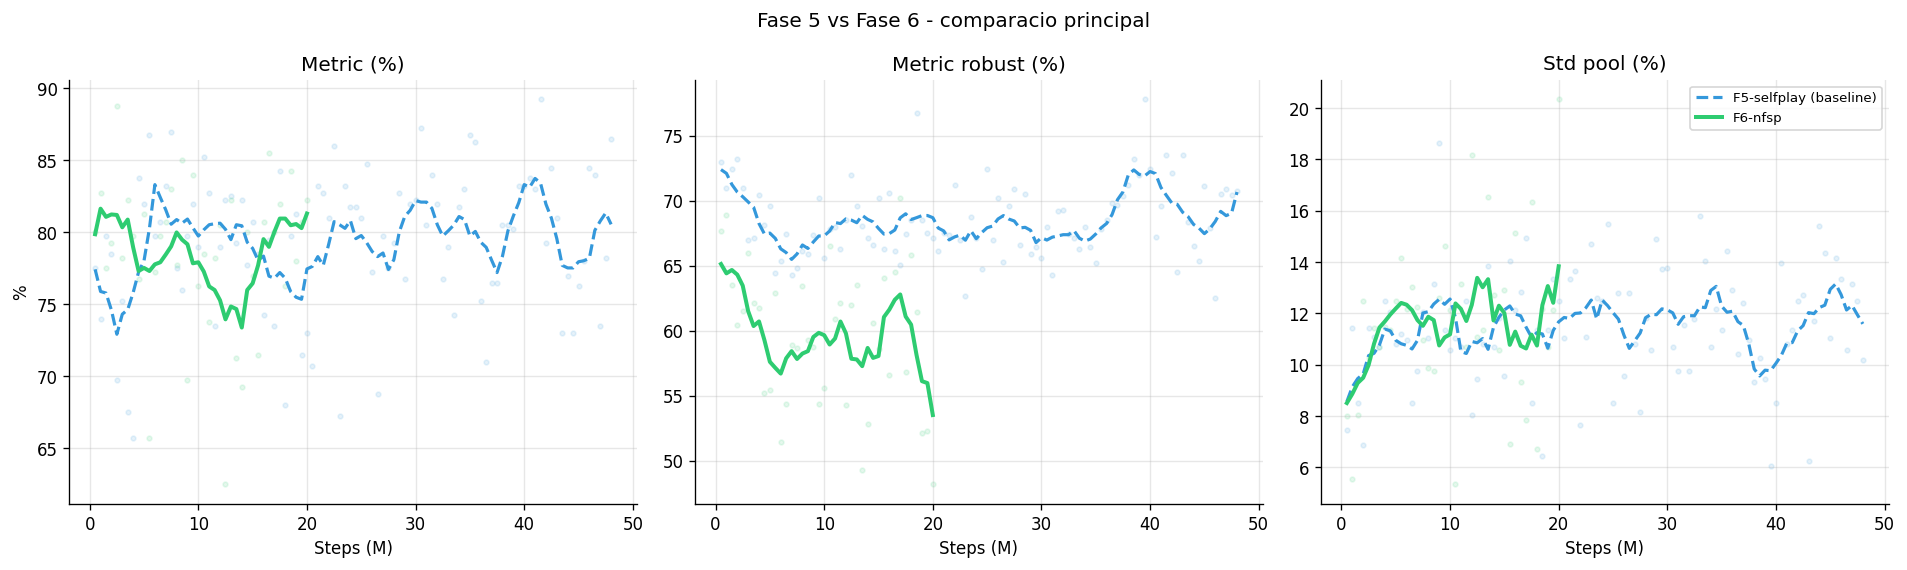

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('Fase 5 vs Fase 6 - comparacio principal', fontsize=12)

blocs = [
    ('metric', 'Metric (%)'),
    ('metric_robust', 'Metric robust (%)'),
    ('std_pool', 'Std pool (%)'),
]

for ax, (col, tit) in zip(axes, blocs):
    for key, info in RUNS.items():
        if key not in dades:
            continue
        df = dades[key]
        if col not in df.columns:
            continue
        d = df.dropna(subset=[col])
        if len(d) == 0:
            continue
        x = d['step'] / 1e6
        ax.scatter(x, d[col], color=info['color'], alpha=0.12, s=8)
        ax.plot(x, suavitzar(d[col], 7), color=info['color'], linestyle=info['ls'], linewidth=info['lw'], label=info['label'])
    ax.set_title(tit)
    ax.set_xlabel('Steps (M)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('%')
axes[2].legend(fontsize=8)
plt.tight_layout()
fig_path = OUT_DIR / 'fase6_corbes_principals.png'
mem_fig_path = MEM_DIR / 'fase6_corbes.pdf'
plt.savefig(fig_path, dpi=140, bbox_inches='tight')
plt.savefig(mem_fig_path, bbox_inches='tight')
print(f'Figura guardada a: {fig_path}')
print(f'Figura guardada a: {mem_fig_path}')
plt.show()

### 4.1 Perfil per variants d'oponent

Aquesta seccio compara WR per variant entre F5 i F6 si les columnes `wr_*` estan disponibles al log.

,run,step,wr_conservador,wr_agressiu,wr_truc_bot,wr_envit_bot,wr_faroler,wr_equilibrat
0,f5_selfplay,39500000,75.0,75.0,85.0,85.0,75.0,90.0
1,f6_nfsp,17000000,75.0,70.0,70.0,65.0,75.0,90.0


Figura guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_wr_variants.png


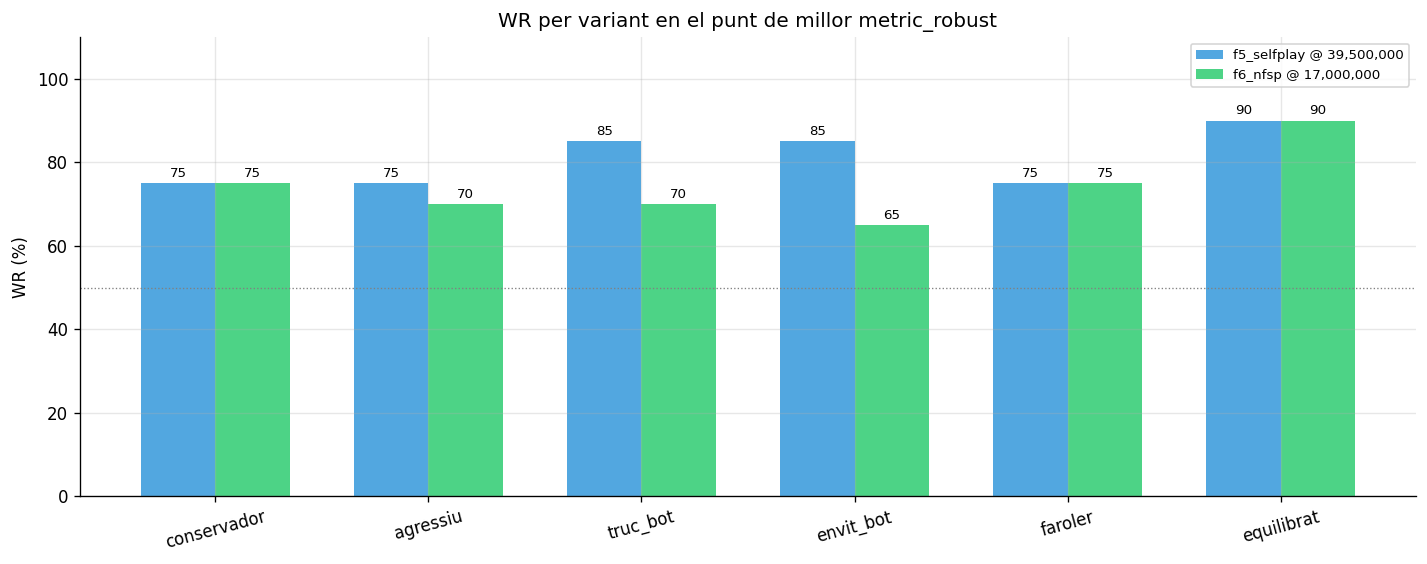

In [6]:
candidats = ['conservador', 'agressiu', 'truc_bot', 'envit_bot', 'faroler', 'equilibrat']
cols_wr = [f'wr_{v}' for v in candidats]

disponibles = [c for c in cols_wr if all(c in dades[k].columns for k in dades)]
if not disponibles:
    print('No hi ha columnes wr_* per variant a tots els logs; seccio omitida.')
else:
    # Escollim per cada run el punt "best_metric_robust" per comparar robustesa real
    files = []
    for key in ['f5_selfplay', 'f6_nfsp']:
        if key not in dades:
            continue
        df = dades[key]
        row = fila_best(df, 'metric_robust', minim=False)
        d = {'run': key, 'step': int(row['step'])}
        for c in disponibles:
            d[c] = float(row[c])
        files.append(d)

    taula_variants = pd.DataFrame(files)
    display(taula_variants)

    x = np.arange(len(disponibles))
    n = len(files)
    w = 0.7 / max(1, n)
    fig, ax = plt.subplots(figsize=(12, 4.8))
    colors = {'f5_selfplay': '#3498db', 'f6_nfsp': '#2ecc71'}

    for i, r in enumerate(files):
        vals = [r[c] for c in disponibles]
        off = (i - n/2 + 0.5) * w
        bars = ax.bar(x + off, vals, w, color=colors.get(r['run'], '#999999'), alpha=0.85, label=f"{r['run']} @ {r['step']:,}")
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, b.get_height()+0.8, f"{v:.0f}", ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('wr_', '') for c in disponibles], rotation=15)
    ax.set_ylabel('WR (%)')
    ax.set_ylim(0, 110)
    ax.set_title('WR per variant en el punt de millor metric_robust')
    ax.axhline(50, color='gray', linestyle=':', lw=0.8)
    ax.legend(fontsize=8)
    plt.tight_layout()
    var_fig = OUT_DIR / 'fase6_wr_variants.png'
    plt.savefig(var_fig, dpi=140, bbox_inches='tight')
    print(f'Figura guardada a: {var_fig}')
    plt.show()

---
## 5. Nash i calibracio (Fase 6)

Analisi centrada en `exploit_vs_sl`, `nash_valid` i calibracio estrategica.

Figura guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_nash_calibracio.png
Figura guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\fase6\fase6_nash.pdf


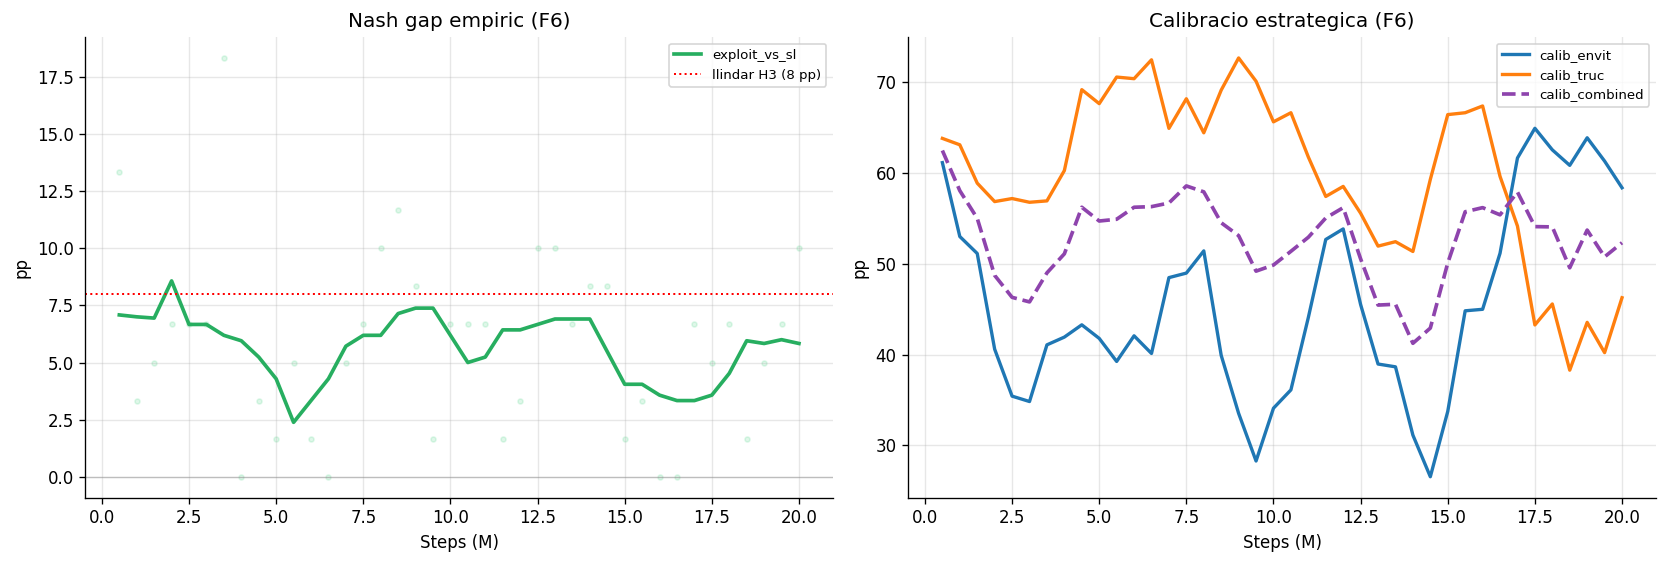

PUNTS CLAU F6
  best_nash_valid: step=16,000,000 | exploit_vs_sl=0.00 pp | metric=80.75%
  best_calibracio: step=7,000,000 | calib_combined=67.37 pp


In [7]:
df6 = dades['f6_nfsp']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

d_exp = df6.dropna(subset=['exploit_vs_sl'])
if len(d_exp):
    x = d_exp['step'] / 1e6
    axes[0].scatter(x, d_exp['exploit_vs_sl'], color='#2ecc71', alpha=0.15, s=9)
    axes[0].plot(x, suavitzar(d_exp['exploit_vs_sl'], 7), color='#27ae60', linewidth=2.2, label='exploit_vs_sl')
axes[0].axhline(8, color='red', linestyle=':', linewidth=1.2, label='llindar H3 (8 pp)')
axes[0].axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)
axes[0].set_title('Nash gap empiric (F6)')
axes[0].set_xlabel('Steps (M)')
axes[0].set_ylabel('pp')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

if 'calib_envit' in df6.columns and 'calib_truc' in df6.columns:
    d_cal = df6.dropna(subset=['calib_envit', 'calib_truc'])
    x = d_cal['step'] / 1e6
    axes[1].plot(x, suavitzar(d_cal['calib_envit'], 5), color='#1f77b4', linewidth=2.0, label='calib_envit')
    axes[1].plot(x, suavitzar(d_cal['calib_truc'], 5), color='#ff7f0e', linewidth=2.0, label='calib_truc')
    axes[1].plot(x, suavitzar((d_cal['calib_envit'] + d_cal['calib_truc'])/2, 5), color='#8e44ad', linewidth=2.2, linestyle='--', label='calib_combined')
axes[1].set_title('Calibracio estrategica (F6)')
axes[1].set_xlabel('Steps (M)')
axes[1].set_ylabel('pp')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / 'fase6_nash_calibracio.png'
mem_fig_path = MEM_DIR / 'fase6_nash.pdf'
plt.savefig(fig_path, dpi=140, bbox_inches='tight')
plt.savefig(mem_fig_path, bbox_inches='tight')
print(f'Figura guardada a: {fig_path}')
print(f'Figura guardada a: {mem_fig_path}')
plt.show()

best_nv = fila_best(df6, 'exploit_vs_sl', minim=True, filtre=(df6['nash_valid'] == 1))
best_cal = fila_best(df6, 'calib_combined', minim=False)
print('PUNTS CLAU F6')
if best_nv is not None:
    print(f"  best_nash_valid: step={int(best_nv['step']):,} | exploit_vs_sl={float(best_nv['exploit_vs_sl']):.2f} pp | metric={float(best_nv['metric']):.2f}%")
else:
    print('  best_nash_valid: no disponible')
if best_cal is not None:
    print(f"  best_calibracio: step={int(best_cal['step']):,} | calib_combined={float(best_cal['calib_combined']):.2f} pp")

### 5.1 Estabilitat temporal de F6

Desglossament per trams d'entrenament per veure si la convergencia Nash es sostinguda o puntual.

In [8]:
df6 = dades['f6_nfsp'].copy().sort_values('step').reset_index(drop=True)
df6['tram'] = pd.qcut(df6['step'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

files = []
for t in ['Q1', 'Q2', 'Q3', 'Q4']:
    d = df6[df6['tram'] == t]
    if len(d) == 0:
        continue
    row = {
        'tram': t,
        'step_min': int(d['step'].min()),
        'step_max': int(d['step'].max()),
        'metric_mitja': float(d['metric'].mean()) if 'metric' in d.columns else np.nan,
        'metric_robust_mitja': float(d['metric_robust'].mean()) if 'metric_robust' in d.columns else np.nan,
        'exploit_vs_sl_mitja': float(d['exploit_vs_sl'].dropna().mean()) if 'exploit_vs_sl' in d.columns else np.nan,
        'n_nash_valid': int((d['nash_valid'] == 1).sum()) if 'nash_valid' in d.columns else 0,
    }
    files.append(row)

taula_trams = pd.DataFrame(files)
display(taula_trams)

tram_csv = OUT_DIR / 'fase6_estabilitat_trams.csv'
taula_trams.to_csv(tram_csv, index=False)
print(f'Taula guardada a: {tram_csv}')

,tram,step_min,step_max,metric_mitja,metric_robust_mitja,exploit_vs_sl_mitja,n_nash_valid
0,Q1,500000,5000000,80.650,62.24849,6.50000,0
1,Q2,5500000,10000000,77.925,57.75776,5.66668,4
2,Q3,10500000,15000000,75.325,59.04081,6.33334,9
3,Q4,15500000,20000000,80.125,59.20289,4.50001,10


Taula guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_estabilitat_trams.csv


---
## 6. Checkpoints i coherencia del run Fase 6

In [9]:
run_dir_f6 = RUNS['f6_nfsp']['path'].parent
esperats = ['best.zip', 'best_robust.zip', 'best_nash.zip', 'best_calib.zip', 'final.zip', 'training_log.csv', 'sl_final.pt']

taula_ckpt = []
for f in esperats:
    p = run_dir_f6 / f
    taula_ckpt.append({
        'fitxer': f,
        'existeix': p.exists(),
        'bytes': p.stat().st_size if p.exists() and p.is_file() else 0,
    })

taula_ckpt = pd.DataFrame(taula_ckpt)
display(taula_ckpt)

ckpt_csv = OUT_DIR / 'fase6_checkpoints.csv'
taula_ckpt.to_csv(ckpt_csv, index=False)
print(f'Checkpoints guardats a: {ckpt_csv}')

,fitxer,existeix,bytes
0,best.zip,True,3687216
1,best_robust.zip,True,3687216
2,best_nash.zip,True,3687218
3,best_calib.zip,True,3687217
4,final.zip,True,3687218
5,training_log.csv,True,7436
6,sl_final.pt,True,941197


Checkpoints guardats a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_checkpoints.csv


---
## 7. Export per a la memoria (Bloc 3 / Fase 6)

Genera un resum en Markdown i un bloc LaTeX base per enganxar a la memoria.

In [10]:
def fmt(v, nd=2):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return 'nan'
    return f'{float(v):.{nd}f}'

df6 = dades['f6_nfsp']
df5 = dades.get('f5_selfplay', None)

b6_m = fila_best(df6, 'metric', minim=False)
b6_mr = fila_best(df6, 'metric_robust', minim=False)
b6_nv = fila_best(df6, 'exploit_vs_sl', minim=True, filtre=(df6['nash_valid'] == 1))
b6_cal = fila_best(df6, 'calib_combined', minim=False)

if df5 is not None:
    b5_m = fila_best(df5, 'metric', minim=False)
    b5_mr = fila_best(df5, 'metric_robust', minim=False)
else:
    b5_m, b5_mr = None, None

h1 = (b5_m is None) or (float(b6_m['metric']) >= float(b5_m['metric']) - 3.0)
h2 = (b5_mr is None) or (float(b6_mr['metric_robust']) >= float(b5_mr['metric_robust']) - 2.0)
h3 = (b6_nv is not None) and (float(b6_nv['exploit_vs_sl']) < 8.0)

# Indicador d'early stopping (si el log conté el comptador)
if 'evals_sense_millora' in df6.columns:
    es_final = df6.sort_values('step').iloc[-1]
    es_count = int(es_final['evals_sense_millora']) if not pd.isna(es_final['evals_sense_millora']) else 0
    es_trigger = es_count >= 3
else:
    es_count = None
    es_trigger = False

md_lines = [
    '# Resum Fase 6 (auto)',
    '',
    '## Resultats principals',
    f"- F6 best metric: {fmt(b6_m['metric'])}% @ step {int(b6_m['step']):,}",
    f"- F6 best metric_robust: {fmt(b6_mr['metric_robust'])}% @ step {int(b6_mr['step']):,}",
    f"- F6 best_nash_valid exploit_vs_sl: {fmt(b6_nv['exploit_vs_sl']) if b6_nv is not None else 'nan'} pp",
    f"- F6 best_calib_combined: {fmt(b6_cal['calib_combined']) if b6_cal is not None else 'nan'} pp",
    f"- Early stop: {'SI' if es_trigger else 'NO/No verificable'}" + (f" (evals_sense_millora final={es_count})" if es_count is not None else ''),
    '',
    '## Validacio hipotesis',
    f"- H1 (no regressio metric): {'VALIDA' if h1 else 'FALLA'}",
    f"- H2 (robustesa): {'VALIDA' if h2 else 'FALLA'}",
    f"- H3 (Nash valid < 8pp): {'VALIDA' if h3 else 'FALLA'}",
]

md_path = OUT_DIR / 'resum_fase6_auto.md'
md_path.write_text('\n'.join(md_lines), encoding='utf-8')
print(f'Markdown guardat a: {md_path}')

tex_lines = [
    '% Bloc auto-generat per Fase 6',
    '\\paragraph{Resum quantitatiu Fase 6.}',
    f"F6 assoleix una \\texttt{{metric}} maxima de {fmt(b6_m['metric'])}\\% al pas {int(b6_m['step']):,}.",
    f"La millor \\texttt{{metric\\_robust}} es {fmt(b6_mr['metric_robust'])}\\%.",
    f"El millor punt Nash valid te \\texttt{{exploit\\_vs\\_sl}}={fmt(b6_nv['exploit_vs_sl']) if b6_nv is not None else 'nan'}~pp.",
    f"La millor calibracio combinada es {fmt(b6_cal['calib_combined']) if b6_cal is not None else 'nan'}~pp.",
    (f"S'observa criteri d'\\textit{{early stopping}} (\\texttt{{evals\\_sense\\_millora}} final={es_count})." if es_count is not None and es_trigger else "No es detecta activacio clara d'\\textit{early stopping} en el log disponible."),
    '',
    f"H1: {'VALIDA' if h1 else 'FALLA'}. H2: {'VALIDA' if h2 else 'FALLA'}. H3: {'VALIDA' if h3 else 'FALLA'}.",
]

tex_path = OUT_DIR / 'resum_fase6_auto.tex'
tex_path.write_text('\n'.join(tex_lines), encoding='utf-8')
print(f'LaTeX guardat a: {tex_path}')

Markdown guardat a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\resum_fase6_auto.md
LaTeX guardat a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\resum_fase6_auto.tex


## 8. Conclusions guiades (esquelet per memoria)

Aquest bloc imprimeix frases curtes orientades a redaccio academica basades en les metriques calculades.

In [11]:
def frase_bool(ok: bool) -> str:
    return 'es valida' if ok else 'no es valida'

print('CONCLUSIONS (draft automatic)\n')
print(f"- H1 {frase_bool(h1)}: F6 manté rendiment global respecte F5 dins el marge definit.")
print(f"- H2 {frase_bool(h2)}: la robustesa de F6 {'millora/mante' if h2 else 'queda per sota'} del baseline F5 segons metric_robust.")
print(f"- H3 {frase_bool(h3)}: s'observa {'aproximacio valida a Nash' if h3 else 'manca de convergencia Nash valida'} amb criteri nash_valid.")

if 'taula_trams' in globals() and len(taula_trams):
    millor_tram = taula_trams.sort_values('exploit_vs_sl_mitja').iloc[0]
    print(f"- El tram mes estable en exploit_vs_sl es {millor_tram['tram']} (mitja={millor_tram['exploit_vs_sl_mitja']:.2f} pp).")

print('\nRecomanacio de redaccio: separar clarament "pic de performance" i "punt de millor estabilitat Nash".')

CONCLUSIONS (draft automatic)

- H1 es valida: F6 manté rendiment global respecte F5 dins el marge definit.
- H2 no es valida: la robustesa de F6 queda per sota del baseline F5 segons metric_robust.
- H3 es valida: s'observa aproximacio valida a Nash amb criteri nash_valid.
- El tram mes estable en exploit_vs_sl es Q4 (mitja=4.50 pp).

Recomanacio de redaccio: separar clarament "pic de performance" i "punt de millor estabilitat Nash".


---
## 9. Checklist de validacio F6 (execucio rapida)

Aquest bloc resumeix en una sola taula els punts critics del run Fase 6:
- coherencia de logs i checkpoints,
- existencia de punts Nash valids,
- consistencia entre rendiment brut, robustesa i exploitabilitat.

In [12]:
# Checklist automatica de validacio F6
import numpy as np
import pandas as pd

if 'dades' not in globals() or 'f6_nfsp' not in dades:
    raise RuntimeError("Executa primer les cel·les de setup i carrega de dades (seccions 1 i 2).")

df6 = dades['f6_nfsp'].copy().sort_values('step').reset_index(drop=True)
df5 = dades.get('f5_selfplay', None)

def _best(df, col, minim=False, filtre=None):
    if col not in df.columns:
        return None
    d = df.copy()
    if filtre is not None:
        d = d[filtre]
    d = d.dropna(subset=[col])
    if len(d) == 0:
        return None
    idx = d[col].idxmin() if minim else d[col].idxmax()
    return d.loc[idx]

def _fmt(v, nd=2):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "nan"
    return f"{float(v):.{nd}f}"

b6_m  = _best(df6, 'metric', minim=False)
b6_mr = _best(df6, 'metric_robust', minim=False)
b6_nv = _best(df6, 'exploit_vs_sl', minim=True, filtre=(df6['nash_valid'] == 1) if 'nash_valid' in df6.columns else None)

b5_m  = _best(df5, 'metric', minim=False) if df5 is not None else None
b5_mr = _best(df5, 'metric_robust', minim=False) if df5 is not None else None

# Hipotesis operatives
h1 = (b5_m is None) or (float(b6_m['metric']) >= float(b5_m['metric']) - 3.0)
h2 = (b5_mr is None) or (float(b6_mr['metric_robust']) >= float(b5_mr['metric_robust']) - 2.0)
h3 = (b6_nv is not None) and (float(b6_nv['exploit_vs_sl']) < 8.0)

n_nash_valid = int((df6['nash_valid'] == 1).sum()) if 'nash_valid' in df6.columns else 0
csv_cols = ['metric', 'metric_robust', 'std_pool', 'sl_loss', 'wr_vs_sl', 'exploit_vs_sl', 'calib_envit', 'calib_truc', 'nash_valid', 'evals_sense_millora']
cols_presentes = sum(1 for c in csv_cols if c in df6.columns)

run_dir_f6 = RUNS['f6_nfsp']['path'].parent if 'RUNS' in globals() and 'f6_nfsp' in RUNS else None
ckpts = ['best.zip', 'best_robust.zip', 'best_nash.zip', 'best_calib.zip', 'final.zip', 'sl_final.pt']
if run_dir_f6 is not None:
    ckpt_ok = all((run_dir_f6 / c).exists() for c in ckpts)
else:
    ckpt_ok = False

taula_check = pd.DataFrame([
    {'item': 'H1 no regressio metric', 'valor': 'OK' if h1 else 'FALLA', 'detall': f"F6={_fmt(b6_m['metric'])}% | F5={_fmt(b5_m['metric'])}%" if b5_m is not None else f"F6={_fmt(b6_m['metric'])}%"},
    {'item': 'H2 robustesa', 'valor': 'OK' if h2 else 'FALLA', 'detall': f"F6={_fmt(b6_mr['metric_robust'])}% | F5={_fmt(b5_mr['metric_robust'])}%" if b5_mr is not None else f"F6={_fmt(b6_mr['metric_robust'])}%"},
    {'item': 'H3 Nash valid', 'valor': 'OK' if h3 else 'FALLA', 'detall': f"exploit_vs_sl={_fmt(b6_nv['exploit_vs_sl'])} pp @ step {int(b6_nv['step']):,}" if b6_nv is not None else 'sense punts nash_valid < 8 pp'},
    {'item': 'Punts nash_valid', 'valor': n_nash_valid, 'detall': 'nombre total de files amb nash_valid=1'},
    {'item': 'Columnes clau CSV', 'valor': f"{cols_presentes}/{len(csv_cols)}", 'detall': ', '.join([c for c in csv_cols if c not in df6.columns]) or 'complet'},
    {'item': 'Checkpoints F6', 'valor': 'OK' if ckpt_ok else 'REVISAR', 'detall': ', '.join(ckpts)},
])

display(taula_check)

# Export curt per memoria
out = OUT_DIR if 'OUT_DIR' in globals() else None
if out is not None:
    out.mkdir(parents=True, exist_ok=True)
    path_csv = out / 'fase6_checklist_validacio.csv'
    taula_check.to_csv(path_csv, index=False)
    print(f"Checklist guardada a: {path_csv}")
else:
    print('OUT_DIR no definit: no s ha exportat CSV.')

,item,valor,detall
0,H1 no regressio metric,OK,F6=88.75% | F5=89.25%
1,H2 robustesa,FALLA,F6=70.24% | F5=77.80%
2,H3 Nash valid,OK,"exploit_vs_sl=0.00 pp @ step 16,000,000"
3,Punts nash_valid,23,nombre total de files amb nash_valid=1
4,Columnes clau CSV,10/10,complet
5,Checkpoints F6,OK,"best.zip, best_robust.zip, best_nash.zip, best..."


Checklist guardada a: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\analisi_fase6\fase6_checklist_validacio.csv
